# Mini Projects: CartPole, FrozenLake, Q-learning, and DQN

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement Q-learning algorithm
- Apply Q-learning to FrozenLake environment
- Apply Q-learning to CartPole environment (with state discretization)
- Understand Deep Q-Network (DQN) concepts
- Train and evaluate RL agents on classic environments

## 🔗 Prerequisites

- ✅ OpenAI Gym setup
- ✅ Understanding of states, actions, rewards
- ✅ Epsilon-Greedy exploration strategy
- ✅ Python knowledge (functions, classes, loops, dictionaries)
- ✅ NumPy knowledge
- ✅ Basic understanding of neural networks (for DQN section)

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 1**:
- Mini projects: applying RL in games like CartPole and FrozenLake, implementing Q-learning and DQN

---

## Introduction

This notebook combines multiple mini projects:
1. **Q-learning on FrozenLake**: Classic grid-world problem with discrete states
2. **Q-learning on CartPole**: Continuous state space requiring discretization
3. **DQN Introduction**: Deep reinforcement learning for high-dimensional states

These projects demonstrate practical RL applications on classic benchmark environments.

## Lesson Brief

This lesson gives students a first practical bridge from small theory examples to recognizable RL tasks.

They will see how the same core ideas appear in environments like FrozenLake and CartPole, even when the implementation details become harder.

Why this matters: students often need one notebook that says, "This is what the theory looks like in a real benchmark."

This lesson is meant to increase confidence before later units go deeper.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Replay buffer: stored experiences for reuse.
- Target network: stabilizes targets.
- Mini-batch: a small training sample.
- Approximator: a neural network replacing the table.

### Quick Check
- Why does DQN need replay?
- Why use a target network?
- What does DQN solve that tabular methods cannot?

### Common Mistakes
- Focusing on network code but missing the algorithm idea.
- Thinking deep RL is unrelated to Q-learning.
- Ignoring stability as the main challenge.


## What you should learn from this notebook

This notebook is the bridge from Unit 1 theory to small practical experiments.

By the end, you should be able to:

- connect MDP ideas to simple environments
- understand the shape of a Q-learning workflow
- see why FrozenLake fits tabular RL well
- understand why CartPole is harder for tabular methods
- treat DQN as a preview of Unit 3, not as the main goal of Unit 1


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

%pip install "gymnasium[classic_control]" numpy matplotlib -q
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import random
from collections import defaultdict

print("✅ Libraries imported!")
print("\nMini Projects: CartPole, FrozenLake, Q-learning, and DQN")
print("=" * 60)

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


✅ Libraries imported!

Mini Projects: CartPole, FrozenLake, Q-learning, and DQN


## Part 1: Q-Learning Algorithm Implementation


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

print("=" * 60)
print("Part 1: Q-Learning Algorithm Implementation")
print("=" * 60)


def q_learning_update(q_table, state, action, reward, next_state, alpha, gamma):
    best_next = np.max(q_table[next_state])
    td_target = reward + gamma * best_next
    td_error = td_target - q_table[state, action]
    q_table[state, action] += alpha * td_error
    return q_table[state, action]


q_demo = np.zeros((5, 4))
updated_value = q_learning_update(
    q_demo,
    state=2,
    action=1,
    reward=10,
    next_state=3,
    alpha=0.1,
    gamma=0.9,
)

print("A single Q-learning update example:")
print("Updated Q[2, 1] =", round(updated_value, 3))
print("\nCore idea:")
print("Q-learning moves the current estimate toward reward + discounted best future value.")

Part 1: Q-Learning Algorithm Implementation
A single Q-learning update example:
Updated Q[2, 1] = 1.0

Core idea:
Q-learning moves the current estimate toward reward + discounted best future value.


## Part 2: Q-Learning on FrozenLake


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

print("\n" + "=" * 60)
print("Part 2: Q-Learning on FrozenLake")
print("=" * 60)

env = gym.make("FrozenLake-v1", is_slippery=False)
q_table = np.zeros((env.observation_space.n, env.action_space.n))
alpha = 0.1
gamma = 0.95
epsilon = 0.2
rewards = []

for episode in range(200):
    state, info = env.reset(seed=episode)
    total_reward = 0
    for _ in range(50):
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(q_table[state]))

        next_state, reward, terminated, truncated, info = env.step(action)
        q_learning_update(q_table, state, action, reward, next_state, alpha, gamma)
        state = next_state
        total_reward += reward
        if terminated or truncated:
            break
    rewards.append(total_reward)

env.close()

print("FrozenLake Q-table shape:", q_table.shape)
print("Average reward over last 50 episodes:", np.mean(rewards[-50:]).round(3))
print("\nWhy this example matters:")
print("FrozenLake has a small discrete state space, so tabular Q-learning is a natural fit.")


Part 2: Q-Learning on FrozenLake
FrozenLake Q-table shape: (16, 4)
Average reward over last 50 episodes: 0.0

Why this example matters:
FrozenLake has a small discrete state space, so tabular Q-learning is a natural fit.


## Part 3: Q-Learning on CartPole (with State Discretization)


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

print("\n" + "=" * 60)
print("Part 3: Q-Learning on CartPole (with State Discretization)")
print("=" * 60)

env = gym.make("CartPole-v1")
obs, info = env.reset(seed=42)

print("One CartPole observation:", obs)
print("Observation dimension:", len(obs))
print("Action space:", env.action_space)

env.close()

print("\nWhy CartPole is harder than FrozenLake:")
print("- CartPole observations are continuous, not small discrete state IDs.")
print("- A plain Q-table does not directly fit this representation.")
print("- One workaround is discretization, but that can be crude and inefficient.")
print("- This motivates neural-network approaches such as DQN later.")


Part 3: Q-Learning on CartPole (with State Discretization)
One CartPole observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation dimension: 4
Action space: Discrete(2)

Why CartPole is harder than FrozenLake:
- CartPole observations are continuous, not small discrete state IDs.
- A plain Q-table does not directly fit this representation.
- One workaround is discretization, but that can be crude and inefficient.
- This motivates neural-network approaches such as DQN later.


## Part 4: Introduction to Deep Q-Network (DQN)


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [5]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

print("\n" + "=" * 60)
print("Part 4: Introduction to Deep Q-Network (DQN)")
print("=" * 60)

print("\nDQN Overview:")
print(" - Uses neural network to approximate Q-function (instead of Q-table)")
print(" - Handles high-dimensional state spaces (e.g., images)")
print(" - Key innovations:")
print(" 1. Experience Replay: Store transitions, sample randomly for training")
print(" 2. Target Network: Separate network for stable Q-targets")
print(" 3. Neural Network: Approximate Q(s,a) for continuous/ high-dim states")

print("\nDQN Architecture:")
print(" Input: State (e.g., image, observation vector)")
print(" Network: Fully connected or CNN layers")
print(" Output: Q-values for each action")

print("\nDQN vs Q-Learning:")
print(" Q-Learning:")
print(" - Uses Q-table (discrete states only)")
print(" - Limited to small state spaces")
print(" - Fast for tabular problems")
print(" DQN:")
print(" - Uses neural network (continuous/high-dim states)")
print(" - Scales to complex problems (e.g., Atari games)")
print(" - Requires more computation and tuning")

print("\nDQN Algorithm (High-Level):")
print(" 1. Initialize Q-network and target network")
print(" 2. For each episode:")
print(" a. Observe state")
print(" b. Choose action using epsilon-greedy (using Q-network)")
print(" c. Take action, store transition in replay buffer")
print(" d. Sample batch from replay buffer")
print(" e. Compute targets using target network")
print(" f. Update Q-network using loss: (Q(s,a) - target)^2")
print(" g. Periodically update target network")

print("\nNote: Full DQN implementation will be covered in Unit 3 (Deep RL)")
print("This is an introduction to the concepts.")

print("\n✅ DQN introduction complete!")


Part 4: Introduction to Deep Q-Network (DQN)

DQN Overview:
 - Uses neural network to approximate Q-function (instead of Q-table)
 - Handles high-dimensional state spaces (e.g., images)
 - Key innovations:
 1. Experience Replay: Store transitions, sample randomly for training
 2. Target Network: Separate network for stable Q-targets
 3. Neural Network: Approximate Q(s,a) for continuous/ high-dim states

DQN Architecture:
 Input: State (e.g., image, observation vector)
 Network: Fully connected or CNN layers
 Output: Q-values for each action

DQN vs Q-Learning:
 Q-Learning:
 - Uses Q-table (discrete states only)
 - Limited to small state spaces
 - Fast for tabular problems
 DQN:
 - Uses neural network (continuous/high-dim states)
 - Scales to complex problems (e.g., Atari games)
 - Requires more computation and tuning

DQN Algorithm (High-Level):
 1. Initialize Q-network and target network
 2. For each episode:
 a. Observe state
 b. Choose action using epsilon-greedy (using Q-network)


## Preview Only: Why DQN appears next

At this point in the course, the goal is **not** to master deep RL yet.

This section is only a preview showing why DQN becomes necessary:

- CartPole observations are continuous
- tabular Q-learning does not scale well here
- neural networks can approximate action values from raw observations

Full DQN treatment belongs to Unit 3.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


Episode   0 | Avg reward (last 30): 36.0 | ε=0.995


Episode  30 | Avg reward (last 30): 22.8 | ε=0.856


Episode  60 | Avg reward (last 30): 27.2 | ε=0.737


Episode  90 | Avg reward (last 30): 21.4 | ε=0.634


Episode 120 | Avg reward (last 30): 19.4 | ε=0.545


Episode 150 | Avg reward (last 30): 28.9 | ε=0.469


Episode 180 | Avg reward (last 30): 43.3 | ε=0.404


Episode 210 | Avg reward (last 30): 51.3 | ε=0.347


Episode 240 | Avg reward (last 30): 37.0 | ε=0.299


Episode 270 | Avg reward (last 30): 45.9 | ε=0.257


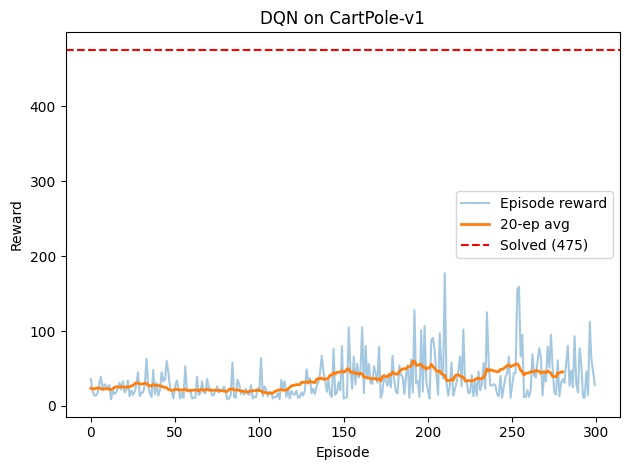

In [6]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
import numpy as np, random, collections, matplotlib.pyplot as plt

torch.manual_seed(42); np.random.seed(42)

env = gym.make('CartPole-v1')

# ── DQN Network ──────────────────────────────────────────────────────────
class DQN(nn.Module):
    def __init__(self, obs=4, act=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs,128), nn.ReLU(),
            nn.Linear(128,128), nn.ReLU(),
            nn.Linear(128, act)
        )
    def forward(self, x): return self.net(x)

policy_net = DQN(); target_net = DQN()
target_net.load_state_dict(policy_net.state_dict())
opt     = optim.Adam(policy_net.parameters(), lr=1e-3)
memory  = collections.deque(maxlen=10000)
GAMMA   = 0.99; EPS = 1.0; EPS_MIN = 0.05; EPS_DECAY = 0.995
BATCH   = 64; rewards_ep = []

for episode in range(300):
    obs,_ = env.reset(); total_r = 0
    for t in range(500):
        if random.random() < EPS:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = policy_net(torch.tensor(obs).float().unsqueeze(0)).argmax().item()
        obs2, r, done, trunc, _ = env.step(action)
        memory.append((obs, action, r, obs2, done or trunc))
        obs = obs2; total_r += r
        # ── Train ────────────────────────────────────────────────────────
        if len(memory) >= BATCH:
            batch = random.sample(memory, BATCH)
            s,a,r_b,s2,d = zip(*batch)
            S=torch.tensor(np.array(s)).float(); A=torch.tensor(a).long()
            R=torch.tensor(r_b).float(); S2=torch.tensor(np.array(s2)).float()
            D=torch.tensor(d).float()
            Q_pred = policy_net(S).gather(1,A.unsqueeze(1)).squeeze()
            with torch.no_grad():
                Q_next = target_net(S2).max(1)[0]
            Q_target = R + GAMMA*Q_next*(1-D)
            loss = nn.MSELoss()(Q_pred, Q_target)
            opt.zero_grad(); loss.backward(); opt.step()
        if done or trunc: break
    EPS = max(EPS*EPS_DECAY, EPS_MIN)
    rewards_ep.append(total_r)
    if episode%50==0: target_net.load_state_dict(policy_net.state_dict())
    if episode%30==0: print(f"Episode {episode:3d} | Avg reward (last 30): {np.mean(rewards_ep[-30:]):.1f} | ε={EPS:.3f}")

env.close()
plt.plot(rewards_ep, alpha=0.4, label="Episode reward")
plt.plot(np.convolve(rewards_ep, np.ones(20)/20, 'valid'), label="20-ep avg", lw=2)
plt.title("DQN on CartPole-v1"); plt.xlabel("Episode"); plt.ylabel("Reward")
plt.axhline(475, color='red', linestyle='--', label="Solved (475)"); plt.legend()
plt.tight_layout(); plt.show()

## Summary

This notebook connected Unit 1 theory to small practical experiments.

### Main takeaways

- Q-learning updates action values from reward and estimated future value.
- FrozenLake is a friendly first environment for tabular RL.
- CartPole is harder because the observation space is continuous.
- DQN is introduced here only as a preview of the next level of RL methods.

### What should be mastered now

At the end of Unit 1, students should be comfortable with:

- the RL interaction loop
- states, actions, rewards, and policies
- simple tabular updates
- why some environments are easy for tables and others are not

### What can wait until later

The details of replay buffers, target networks, and deep RL training stability belong to Unit 3.

## 📚 References & Further Reading

**Papers:**
- Watkins & Dayan (1992) — [Q-Learning](https://link.springer.com/article/10.1007/BF00992698)
- Mnih et al. (2015) — [DQN: Human-level control via deep RL](https://www.nature.com/articles/nature14236)
- Van Hasselt et al. (2016) — [Double DQN](https://arxiv.org/abs/1509.06461)

**OpenAI Gym:** [Gymnasium Documentation](https://gymnasium.farama.org/)

**State-of-the-Art:** DQN variants power game-playing AI and robotics controllers at Google DeepMind.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


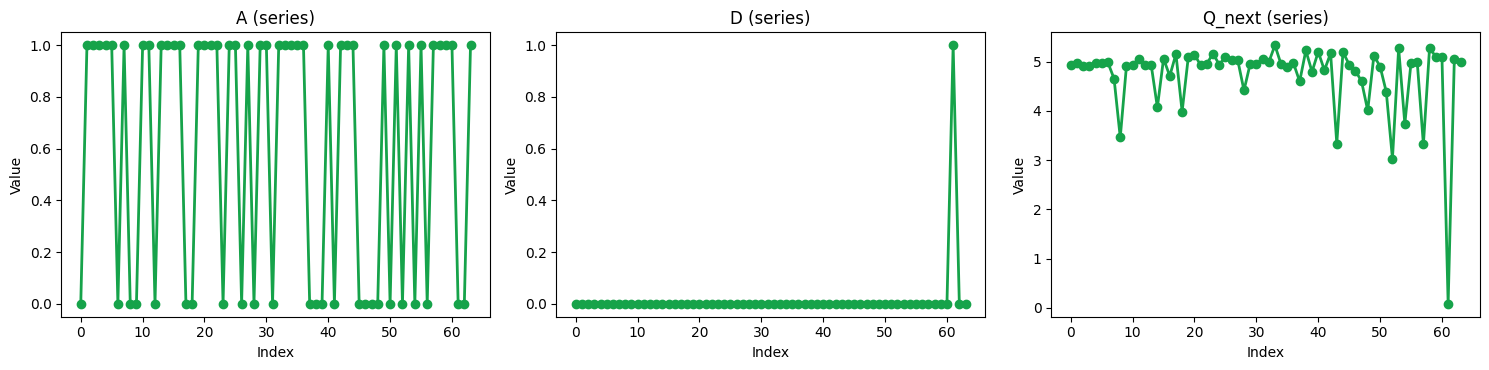

In [7]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Mini-projects help students connect theory to practice by showing how environment choice, algorithm choice, and debugging fit together.

**If students remember one idea:** A project is not only about getting a score. It is about explaining why a method fits a task and how to evaluate it.

**Quick check before moving on:**
- Can you explain why one project may suit tabular methods while another may need deep RL?
- Can you describe what you would monitor while testing a simple RL mini-project?

**Bridge to the next step:** This closes Unit 1 and prepares students for classical prediction and control algorithms in Unit 2.
